# Lattice Boltzmann Method (LBM) problem

In this notebook, we solve the diffusion equation
$$
\partial_t \rho = D \partial_{xx} \rho
$$

using $D1Q3$ lattice with velocities: $c_i = {-1,0,+1} $ and populations $f_0,f_1,f_2$

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [2]:
# Parameters
Nx = 200          # number of lattice points
Nt = 500          # number of time steps

# D1Q3 velocities: left, rest, right
c = np.array([-1, 0, 1])

# Weights for D1Q3 diffusion model
w = np.array([1/6, 2/3, 1/6])

# Relaxation parameter
omega = 1.0

# Diffusion coefficient for D1Q3:
# D = cs^2 * (1/omega - 1/2), where cs^2 = 1/3
D = (1/3) * (1/omega - 0.5)
print("Diffusion coefficient D =", D)

Diffusion coefficient D = 0.16666666666666666


## Initialization

In [3]:
# Initial condition: Gaussian bump
x = np.arange(Nx)
rho = 1.0 + 0.5 * np.exp(-((x - Nx//2)**2) / (2 * 10**2))

# Initialize distributions at equilibrium
f = np.zeros((3, Nx))
for i in range(3):
    f[i, :] = w[i] * rho


## LBM Time evolution

In [4]:
# Store profiles for plotting
snapshots = {}

# LBM time evolution
for t in range(Nt + 1):

    # Macroscopic density
    rho = np.sum(f, axis=0)

    if t in [0, 50, 100, 200, 500]:
        snapshots[t] = rho.copy()

    # Equilibrium distribution
    feq = np.zeros_like(f)
    for i in range(3):
        feq[i, :] = w[i] * rho

    # 1. Collision step
    f = f - omega * (f - feq)

    # 2. Streaming step
    # c[0] = -1: shift left
    # c[1] =  0: no shift
    # c[2] = +1: shift right
    for i in range(3):
        f[i, :] = np.roll(f[i, :], c[i])


## Plotting

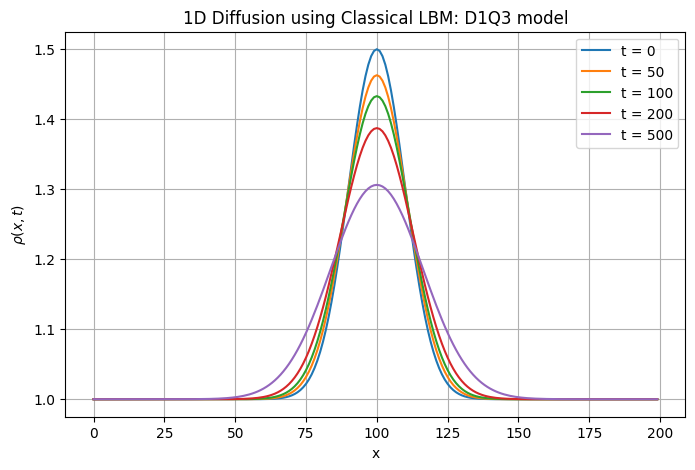

In [5]:
plt.figure(figsize=(8, 5))
for t, profile in snapshots.items():
    plt.plot(x, profile, label=f"t = {t}")

plt.xlabel("x")
plt.ylabel(r"$\rho(x,t)$")
plt.title("1D Diffusion using Classical LBM: D1Q3 model")
plt.legend()
plt.grid(True)
plt.show()